In [1]:
# Kaggle API is needed to download datasets from Kaggle directly
!pip install kaggle
# make directory
!mkdir -p ~/kaggle
#move it to the kaggle directory, ~ represents the home directory of the current user
!cp kaggle.json ~/kaggle/
# Set the read and write permissions for the file:
!chmod 600 ~/kaggle/kaggle.json
# Download the dataset as a zip file
!kaggle datasets download -d ankit1743/skyview-an-aerial-landscape-dataset
# Unzip the data
!unzip /content/skyview-an-aerial-landscape-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Aerial_Landscapes/Lake/601.jpg  
  inflating: Aerial_Landscapes/Lake/602.jpg  
  inflating: Aerial_Landscapes/Lake/603.jpg  
  inflating: Aerial_Landscapes/Lake/604.jpg  
  inflating: Aerial_Landscapes/Lake/605.jpg  
  inflating: Aerial_Landscapes/Lake/606.jpg  
  inflating: Aerial_Landscapes/Lake/607.jpg  
  inflating: Aerial_Landscapes/Lake/608.jpg  
  inflating: Aerial_Landscapes/Lake/609.jpg  
  inflating: Aerial_Landscapes/Lake/610.jpg  
  inflating: Aerial_Landscapes/Lake/611.jpg  
  inflating: Aerial_Landscapes/Lake/612.jpg  
  inflating: Aerial_Landscapes/Lake/613.jpg  
  inflating: Aerial_Landscapes/Lake/614.jpg  
  inflating: Aerial_Landscapes/Lake/615.jpg  
  inflating: Aerial_Landscapes/Lake/616.jpg  
  inflating: Aerial_Landscapes/Lake/617.jpg  
  inflating: Aerial_Landscapes/Lake/618.jpg  
  inflating: Aerial_Landscapes/Lake/619.jpg  
  inflating: Aerial_Landscapes/Lake/620.jpg  
  inflating: Aerial_Landscape

In [2]:
import os
# Define the dataset path
dataset_path = '/content/Aerial_Landscapes'
# Get the folder names as labels
labels = os.listdir(dataset_path)
print('Labels:', labels)
print(f'No of Classes = {len(labels)}')

Labels: ['Beach', 'Residential', 'Lake', 'Grassland', 'Port', 'Mountain', 'Parking', 'Airport', 'Railway', 'Forest', 'Highway', 'River', 'Desert', 'Agriculture', 'City']
No of Classes = 15


In [5]:
from sklearn.model_selection import train_test_split

# Prepare the list of image paths and their corresponding labels
image_paths = []
image_labels = []
from sklearn.model_selection import train_test_split

# Prepare the list of image paths and their corresponding labels
image_paths = []
image_labels = []

for label in labels:
    folder_path = os.path.join(dataset_path, label)
    # Get all image files in the folder
    for img_file in os.listdir(folder_path):
        image_paths.append(os.path.join(folder_path, img_file))
        image_labels.append(label)

# Split into train and temp (validation + test) sets
train_paths, temp_paths, train_labels, temp_labels = train_test_split(image_paths, image_labels, test_size=0.3, stratify=image_labels, random_state=27)
# Split temp into validation and test sets
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=27)

print("train, val, test sizes:")
print(len(train_paths), len(val_paths), len(test_paths))

train, val, test sizes:
8400 1800 1800


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Custom Dataset Class for our project or task
class ImageDataset(Dataset):
    def __init__(self, image_paths, image_labels, transform=None):
        self.image_paths = image_paths
        self.image_labels = image_labels
        self.transform = transform
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)
        # Get label
        label = self.image_labels[idx]
        return image, label


In [9]:
import torchvision.transforms as transforms
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels
    transforms.ToTensor(), # Convert image to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
# Create datasets
train_dataset = ImageDataset(train_paths, train_labels, transform=transform)
val_dataset = ImageDataset(val_paths, val_labels, transform=transform)
test_dataset = ImageDataset(test_paths, test_labels, transform=transform)

# Hyperparameters
batch_size = 32
num_workers = 1

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


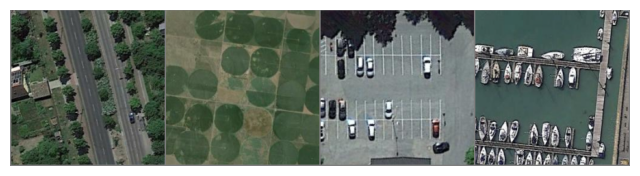

Labels:  Highway Agriculture Parking Port


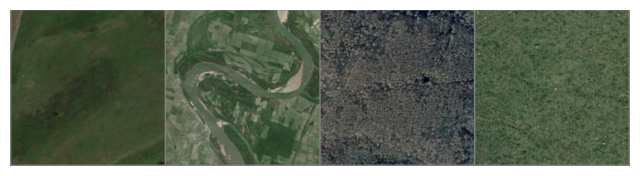

Labels:  Grassland River Forest Grassland


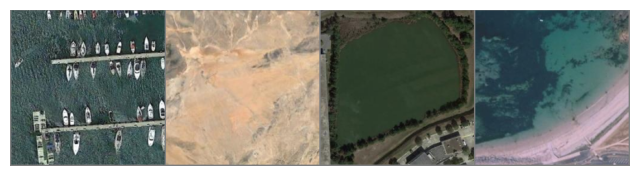

Labels:  Port Desert Lake Beach


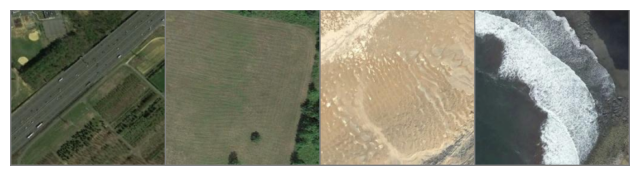

Labels:  Highway Grassland Desert Beach


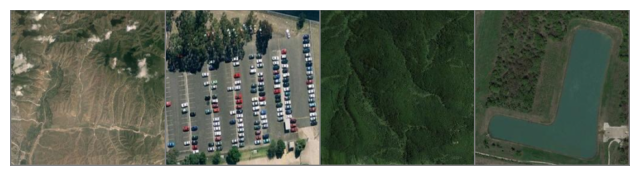

Labels:  Mountain Parking Forest Lake


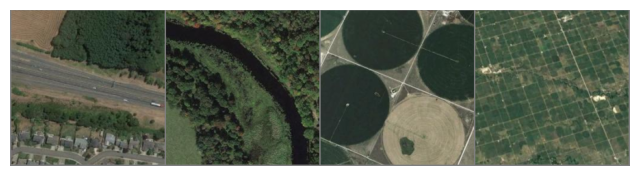

Labels:  Highway River Agriculture Agriculture


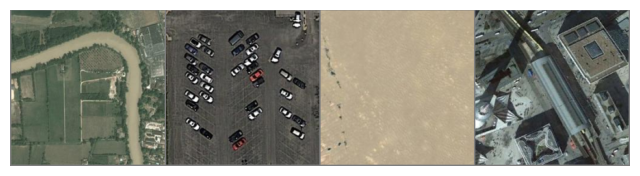

Labels:  River Parking Desert Railway


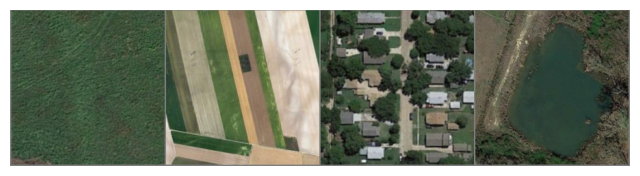

Labels:  Grassland Agriculture Residential Lake


In [11]:
## Visualize a few images and labels
import matplotlib.pyplot as plt
import torchvision
import numpy as np


## imshow method that displays images
def imshow(img, mean, std):
    # Unnormalize
    img = img * std[:, None, None] + mean[:, None, None]
    npimg = img.numpy()
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Define mean and std for unnormalization
mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

# Loop to display 4 images at a time
batch_size = 4
for i in range(0, len(images), batch_size):
    # Select a batch of 4 images and labels
    image_batch = images[i:i+batch_size]
    label_batch = labels[i:i+batch_size]

    # Show the images in the batch
    imshow(torchvision.utils.make_grid(image_batch), mean, std)

    # Print the labels for the current batch of images
    print('Labels: ', ' '.join(f'{label_batch[j]}' for j in range(len(label_batch))))




In [19]:
## Loading Resnet50 pretrained weights
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
print("Model loaded succesfully")

Model loaded succesfully


In [28]:
# Make use of GPU (If we have access to it)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(set(train_labels))  # adjust if train_labels isn't a flat list of ints
print(f"Number of classes: {num_classes}")
print("Layer names for the Model")
for name, _ in model.named_modules():
    print(name)

Number of classes: 15
Layer names for the Model

conv1
bn1
relu
maxpool
layer1
layer1.0
layer1.0.conv1
layer1.0.bn1
layer1.0.conv2
layer1.0.bn2
layer1.0.conv3
layer1.0.bn3
layer1.0.relu
layer1.0.downsample
layer1.0.downsample.0
layer1.0.downsample.1
layer1.1
layer1.1.conv1
layer1.1.bn1
layer1.1.conv2
layer1.1.bn2
layer1.1.conv3
layer1.1.bn3
layer1.1.relu
layer1.2
layer1.2.conv1
layer1.2.bn1
layer1.2.conv2
layer1.2.bn2
layer1.2.conv3
layer1.2.bn3
layer1.2.relu
layer2
layer2.0
layer2.0.conv1
layer2.0.bn1
layer2.0.conv2
layer2.0.bn2
layer2.0.conv3
layer2.0.bn3
layer2.0.relu
layer2.0.downsample
layer2.0.downsample.0
layer2.0.downsample.1
layer2.1
layer2.1.conv1
layer2.1.bn1
layer2.1.conv2
layer2.1.bn2
layer2.1.conv3
layer2.1.bn3
layer2.1.relu
layer2.2
layer2.2.conv1
layer2.2.bn1
layer2.2.conv2
layer2.2.bn2
layer2.2.conv3
layer2.2.bn3
layer2.2.relu
layer2.3
layer2.3.conv1
layer2.3.bn1
layer2.3.conv2
layer2.3.bn2
layer2.3.conv3
layer2.3.bn3
layer2.3.relu
layer3
layer3.0
layer3.0.conv1
layer3

In [32]:
## Use summary method from Pytorch
from torchsummary import summary
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.preprocessing import LabelEncoder

# ---- Encode string labels into integers ----
label_encoder = LabelEncoder()
label_encoder.fit(image_labels)

train_labels_enc = label_encoder.transform(train_labels)
val_labels_enc = label_encoder.transform(val_labels)
test_labels_enc = label_encoder.transform(test_labels)

## This part is reimplemented as now we would like to have encoded labels
train_dataset = ImageDataset(train_paths, train_labels_enc, transform=transform)
val_dataset = ImageDataset(val_paths, val_labels_enc, transform=transform)
test_dataset = ImageDataset(test_paths, test_labels_enc, transform=transform)

batch_size = 32
num_workers = 1

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)



## We would like to fine tune for our task,
# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last conv block (layer4)
for param in model.layer4.parameters():
    param.requires_grad = True
# The FC layer output should be modified to match the number of claseses of our target problem
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)# move to gpu

# ---- Loss & optimizer ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# ---- Training ----
num_epochs = 10
best_val_acc = 0.0

for epoch in range(num_epochs):
    # --- Training loop ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss = train_loss + loss.item() * images.size(0) # a compact way to write loss
        train_correct =  train_correct + (outputs.argmax(1) == labels).sum().item()
        train_total = train_total + labels.size(0) # total no of train samples

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # --- Validation loop ---, remember to have the model in eval
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss = val_loss + loss.item() * images.size(0)
            val_correct = val_correct+ (outputs.argmax(1) == labels).sum().item()
            val_total = val_total + labels.size(0) # total number of samples

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    # if val accuracy is better than best, then save these weights
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pth")

# ---- Test evaluation ----
# load the weights of the best model so far
model.load_state_dict(torch.load("best_resnet50.pth"))
model.eval()

test_loss, test_correct, test_total = 0.0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss = test_loss + loss.item() * images.size(0)
        test_correct = test_correct+ (outputs.argmax(1) == labels).sum().item()
        test_total = test_total + labels.size(0)

test_loss = test_loss / test_total
test_acc = test_correct / test_total

print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Epoch 1/10 Train Loss: 0.1481 Acc: 0.9724 | Val Loss: 0.1071 Acc: 0.9767
Epoch 2/10 Train Loss: 0.0229 Acc: 0.9939 | Val Loss: 0.1171 Acc: 0.9778
Epoch 3/10 Train Loss: 0.0124 Acc: 0.9971 | Val Loss: 0.1133 Acc: 0.9756
Epoch 4/10 Train Loss: 0.0114 Acc: 0.9967 | Val Loss: 0.1531 Acc: 0.9744
Epoch 5/10 Train Loss: 0.0127 Acc: 0.9964 | Val Loss: 0.1475 Acc: 0.9750
Epoch 6/10 Train Loss: 0.0099 Acc: 0.9977 | Val Loss: 0.1475 Acc: 0.9733
Epoch 7/10 Train Loss: 0.0046 Acc: 0.9990 | Val Loss: 0.1136 Acc: 0.9761
Epoch 8/10 Train Loss: 0.0046 Acc: 0.9983 | Val Loss: 0.1413 Acc: 0.9789
Epoch 9/10 Train Loss: 0.0043 Acc: 0.9992 | Val Loss: 0.1597 Acc: 0.9739
Epoch 10/10 Train Loss: 0.0043 Acc: 0.9989 | Val Loss: 0.1339 Acc: 0.9761
Test Loss: 0.1182 | Test Accuracy: 0.9756
